In [3]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=5, suppress=True)

In [4]:
from dataclasses import dataclass

import numpy as np

#from dynprolib.pyfriendly import MutualFundConfig
from portfolio_core import (
    MutualFundConfig,
    MutualFundModel,
    apply_inverse_basis_chain,
    build_model_arrays,
    cartesian_grid,
    gauss_hermite_multinormal,
    linear_spline_basis,
    model_inverse_utility,
    model_utility,
    tensor_basis_interpolate,
    uniform_nodes,
    debt_to_farm_asset_ratio,
    resulting_dfa_after_trade,
    mutual_vmaxh,
    solve_mutual_coefficients,
    mutual_transition_next_state
)




In [5]:
from time import perf_counter

# Benchmark the three search modes on the same workload.
cfg_profile = MutualFundConfig()
cfg_profile.CRRA = True
cfg_profile.Ee = (0.0, 0.0, 0.0)
cfg_profile.var_cov = (
    (0.030186, 0.0, 0.0),
    (0.0, 0.017292, 0.0),
    (0.0, 0.0, 0.026941),
)
cfg_profile.n = (7, 7, 5, 21)
cfg_profile.q = 41
cfg_profile.q2 = 25
cfg_profile.qf = 21
cfg_profile.m = (3, 3, 3)
cfg_profile.T = 19
cfg_profile.t1 = 1
cfg_profile.q_batch = 4
cfg_profile.q_batch_max_rows = 100_000
cfg_profile.value_backend = "numba"
cfg_profile.search_mode = "vectorized"

arrays_profile = build_model_arrays(cfg_profile)
shock_nodes_profile, shock_weights_profile = gauss_hermite_multinormal(arrays_profile['m'], arrays_profile['Ee'], arrays_profile['VarCov'])
state_nodes_profile = [
    uniform_nodes(int(arrays_profile['n'][d]), float(arrays_profile['smin'][d]), float(arrays_profile['smax'][d]))
    for d in range(len(arrays_profile['n']))
]
state_grid_profile = cartesian_grid(state_nodes_profile)
active_states_profile = state_grid_profile[state_grid_profile[:, 3] > 1.0]
coeffs_profile = None

_ = mutual_vmaxh(
    active_states_profile[:4], coeffs_profile, cfg_profile.T, cfg_profile, arrays_profile, shock_nodes_profile, shock_weights_profile
)

results = {}
for mode in ['matlab', 'vectorized', 'two_stage']:
    cfg_profile.search_mode = mode
    cfg_profile.q_coarse_step = 4
    cfg_profile.q_refine_radius = 4
    t0 = perf_counter()
    x_mode, xm_mode, v_mode = mutual_vmaxh(
        active_states_profile, coeffs_profile, cfg_profile.T, cfg_profile, arrays_profile, shock_nodes_profile, shock_weights_profile
    )
    results[mode] = {
        'time': perf_counter() - t0,
        'x': x_mode,
        'xm': xm_mode,
        'v': v_mode,
    }

baseline = results['matlab']
print("Search-mode benchmark on the same workload")
for mode in ['matlab', 'vectorized', 'two_stage']:
    elapsed = results[mode]['time']
    print(f"{mode:10s}: {elapsed:.4f} s")
print(f"speedup(vectorized vs matlab): {baseline['time'] / max(results['vectorized']['time'], 1e-12):.3f}x")
print(f"speedup(two_stage vs matlab)  : {baseline['time'] / max(results['two_stage']['time'], 1e-12):.3f}x")
print(f"max |x diff| vectorized       : {np.max(np.abs(results['vectorized']['x'] - baseline['x'])):.6g}")
print(f"max |xm diff| vectorized      : {np.max(np.abs(results['vectorized']['xm'] - baseline['xm'])):.6g}")
print(f"max |v diff| vectorized       : {np.max(np.abs(results['vectorized']['v'] - baseline['v'])):.6g}")
print(f"max |x diff| two_stage        : {np.max(np.abs(results['two_stage']['x'] - baseline['x'])):.6g}")
print(f"max |xm diff| two_stage       : {np.max(np.abs(results['two_stage']['xm'] - baseline['xm'])):.6g}")
print(f"max |v diff| two_stage        : {np.max(np.abs(results['two_stage']['v'] - baseline['v'])):.6g}")
print(f"q={cfg_profile.q}, q2={cfg_profile.q2}, qf={cfg_profile.qf}, shock nodes={shock_nodes_profile.shape[0]}, states={active_states_profile.shape[0]}")

Search-mode benchmark on the same workload
matlab    : 9.0859 s
vectorized: 2.1448 s
two_stage : 1.5974 s
speedup(vectorized vs matlab): 4.236x
speedup(two_stage vs matlab)  : 5.688x
max |x diff| vectorized       : 2000
max |xm diff| vectorized      : 3.17944e+06
max |v diff| vectorized       : 0.282966
max |x diff| two_stage        : 2000
max |xm diff| two_stage       : 6e+06
max |v diff| two_stage        : 3.06449
q=41, q2=25, qf=21, shock nodes=27, states=4900


# Replication

In [18]:
import time
import numpy as np
import pandas as pd

# Table-8 replication for the model with mutual funds.
# Paper setup uses: initial wealth $1,000,000, x-grid q=41, mutual-fund grid q2=25.
rng = np.random.default_rng(42)#np.random.default_rng(42)
n_sims = 500 #500
n_years = 10 #10

timings = {
    "solve_coefficients": 0.0,
    "build_arrays": 0.0,
    "quadrature_setup": 0.0,
    "optimize_controls": 0.0,
    "draw_shocks": 0.0,
    "state_transition_active": 0.0,
    "state_transition_out": 0.0,
    "summary_update": 0.0,
    "format_output": 0.0,
}
run_t0 = time.perf_counter()

model = MutualFundModel()
cfg = model.config
cfg.Ee = (0.0, 0.0, 0.0)
#cfg.theta=0.0

cfg.search_mode = "vectorized"  # 'matlab', 'vectorized', or 'two_stage'
cfg.cost_scale_eta = 1.0
cfg.value_backend = "numba"
cfg.cost_scale_eta = 1.0
cfg.cost_scale_ref = 600.0
cfg.CRRA = True   # Set to False to run CARA utility mode.
cfg.m = (3, 3, 3)
cfg.dau = 0.7 #Credit limit parameter from paper.
cfg.var_cov = (
    (0.030186, 0.0, 0.0),
    (0.0, 0.017292, 0.0),
    (0.0, 0.0, 0.026941),
)


_mutual_copt_cache = {}

t0 = time.perf_counter()

print(f"Solving coefficients with q={cfg.q}, q2={cfg.q2}...")
cache_key = (
    cfg.n, cfg.q, cfg.q2, cfg.m, cfg.T, cfg.t1, cfg.theta, cfg.b,
    cfg.dau, bool(cfg.CRRA), cfg.Ee, cfg.var_cov
)

if cache_key not in _mutual_copt_cache:
    _mutual_copt_cache[cache_key] = solve_mutual_coefficients(cfg)
copt = _mutual_copt_cache[cache_key]
print("Done solving.")
#copt = _mutual_copt_cache
timings["solve_coefficients"] += time.perf_counter() - t0

t0 = time.perf_counter()
arrays = build_model_arrays(cfg)
timings["build_arrays"] += time.perf_counter() - t0

t0 = time.perf_counter()
shock_nodes, shock_weights = gauss_hermite_multinormal(arrays["m"], arrays["Ee"], arrays["VarCov"])
mean_e = np.asarray(cfg.Ee, dtype=float)
cov_e = np.asarray(cfg.var_cov, dtype=float)
timings["quadrature_setup"] += time.perf_counter() - t0

# Table-8 initial state from paper.
initial_wealth = 1_000_000.0
states = np.zeros((n_sims, 4), dtype=float)
states[:, 0] = 365.0        # R_0
states[:, 1] = 1775.0       # P_0
states[:, 2] = 600.0        # L_0
states[:, 3] = initial_wealth

summary_rows = [
    {
        "Year": 0,
        "Expected net wealth ($)": states[:, 3].mean(),
        "St. dev. of net wealth ($)": np.nan,
        "Expected farmland (acres)": states[:, 2].mean(),
        "Prob. of exiting farming": 0.0,
    }
]

for year in range(1, n_years + 1):
    print(f"Year {year}/{n_years} - Simulating transitions for {n_sims} farmers...")
    # MATLAB pathT.m: yr=0..years-1, c1=copt(:,yr+1), and t passed to vmaxh is yr.
    yr_idx = year - 1
    coeffs_t = copt[:, yr_idx]
    t_eval = yr_idx

    # Follow MATLAB "ini" set: active farming states are L >= sminv(3)-1 and W > 0.
    active_mask = (states[:, 2] >= (arrays["sminv"][2] - 1.0)) & (states[:, 3] > 0.0)
    active_idx = np.where(active_mask)[0]

    next_states = states.copy()

    if active_idx.size > 0:
        active_states = states[active_idx]

        t0 = time.perf_counter()
        x_opt, xm_opt, _ = mutual_vmaxh(
            active_states, coeffs_t, t_eval, cfg, arrays, shock_nodes, shock_weights
        )
        timings["optimize_controls"] += time.perf_counter() - t0

        t0 = time.perf_counter()
        shocks = rng.multivariate_normal(mean=mean_e, cov=cov_e, size=active_idx.size)
        timings["draw_shocks"] += time.perf_counter() - t0
        
        t0 = time.perf_counter()
        next_active = mutual_transition_next_state(
            active_states, x_opt, xm_opt, shocks, cfg, arrays["sminv"], arrays["smaxv"]
        )
        next_states[active_idx] = next_active
        timings["state_transition_active"] += time.perf_counter() - t0

    # Follow MATLAB "outi" transition: all non-active states are absorbing out-of-farming states.
    t0 = time.perf_counter()
    out_idx = np.where(~active_mask)[0]
    if out_idx.size > 0:
        next_states[out_idx, 2] = 0.0
        positive_wealth = next_states[out_idx, 3] >= 0.0
        next_states[out_idx[positive_wealth], 3] = cfg.EgRM * next_states[out_idx[positive_wealth], 3]
        next_states[out_idx[~positive_wealth], 3] = (1.0 + cfg.rn) * next_states[out_idx[~positive_wealth], 3]
    timings["state_transition_out"] += time.perf_counter() - t0

    t0 = time.perf_counter()
    states = next_states
    exited = (states[:, 2] < 1.0) | (states[:, 3] <= 0.0)

    summary_rows.append(
        {
            "Year": year,
            "Expected net wealth ($)": states[:, 3].mean(),
            "St. dev. of net wealth ($)": states[:, 3].std(ddof=1),
            "Expected farmland (acres)": states[:, 2].mean(),
            "Prob. of exiting farming": exited.mean(),
        }
    )
    timings["summary_update"] += time.perf_counter() - t0

mutual_estimates_df = pd.DataFrame(summary_rows)

t0 = time.perf_counter()
table_display = mutual_estimates_df.copy()
table_display["Expected net wealth ($)"] = table_display["Expected net wealth ($)"].map(lambda v: f"{v:,.0f}")
table_display["St. dev. of net wealth ($)"] = table_display["St. dev. of net wealth ($)"].map(
    lambda v: "-" if pd.isna(v) else f"{v:,.0f}"
)
table_display["Expected farmland (acres)"] = table_display["Expected farmland (acres)"].map(lambda v: f"{v:,.0f}")
table_display["Prob. of exiting farming"] = table_display["Prob. of exiting farming"].map(lambda v: f"{v:.3f}")
timings["format_output"] += time.perf_counter() - t0

total_runtime = time.perf_counter() - run_t0
timing_df = pd.DataFrame(
    [{"Step": k, "Seconds": v} for k, v in timings.items()]
).sort_values("Seconds", ascending=False)
timing_df["Share (%)"] = np.where(total_runtime > 0.0, 100.0 * timing_df["Seconds"] / total_runtime, 0.0)

print(f"Total Table 8 runtime: {total_runtime:.3f}s")
print("Step timing (sorted):")
for _, row in timing_df.iterrows():
    print(f"  {row['Step']:<24} {row['Seconds']:>8.3f}s   {row['Share (%)']:>6.2f}%")
if not timing_df.empty:
    slowest = timing_df.iloc[0]
    print(f"Longest step: {slowest['Step']} ({slowest['Seconds']:.3f}s)")

table8_step_timing = timing_df.reset_index(drop=True)

table_display

Solving coefficients with q=41, q2=25...
Done solving.
Year 1/10 - Simulating transitions for 500 farmers...
Year 2/10 - Simulating transitions for 500 farmers...
Year 3/10 - Simulating transitions for 500 farmers...
Year 4/10 - Simulating transitions for 500 farmers...
Year 5/10 - Simulating transitions for 500 farmers...
Year 6/10 - Simulating transitions for 500 farmers...
Year 7/10 - Simulating transitions for 500 farmers...
Year 8/10 - Simulating transitions for 500 farmers...
Year 9/10 - Simulating transitions for 500 farmers...
Year 10/10 - Simulating transitions for 500 farmers...
Total Table 8 runtime: 113.514s
Step timing (sorted):
  solve_coefficients        108.021s    95.16%
  optimize_controls           5.482s     4.83%
  draw_shocks                 0.002s     0.00%
  format_output               0.001s     0.00%
  quadrature_setup            0.001s     0.00%
  state_transition_active     0.001s     0.00%
  summary_update              0.000s     0.00%
  state_transition_ou

,Year,Expected net wealth ($),St. dev. of net wealth ($),Expected farmland (acres),Prob. of exiting farming
0,0,"1,000,000",-,600,0.000
1,1,"1,069,813","168,529",600,0.000
2,2,"1,144,909","268,361",654,0.002
3,3,"1,241,602","353,393",743,0.004
4,4,"1,359,770","465,528",834,0.020
5,5,"1,492,199","589,715",894,0.052
6,6,"1,624,063","720,736",931,0.064
7,7,"1,777,388","841,106",946,0.090
8,8,"1,965,490","988,901",974,0.102
9,9,"2,152,876","1,142,193",955,0.116


In [19]:
# Use the already formatted table and makecell-ready headers, then save to LaTeX.
metric_makecell = {
    "Expected net wealth ($)": r"\makecell{Expected net\\wealth (\$)}",
    "St. dev. of net wealth ($)": r"\makecell{St. dev. of\\net wealth (\$)}",
    "Expected farmland (acres)": r"\makecell{Expected farmland\\(acres)}",
    "Prob. of exiting farming": r"\makecell{Prob. of exiting\\farming}",
}
table8_makecell = table_display.rename(columns=metric_makecell)

latex_str = table8_makecell.to_latex(
    index=False,
    escape=False,  # keep \makecell commands
    column_format="cccccc",
    caption="Table 8-style policy table (model with mutual fund)",
    label="tab:table8_mutual_makecell",
)

tex_path = "Tables/table8_makecell.tex"
with open(tex_path, "w") as f:
    f.write(latex_str)

print(f"Saved LaTeX table to: {tex_path}")
print("Add \\usepackage{makecell} to your LaTeX preamble.")


Saved LaTeX table to: Tables/table8_makecell.tex
Add \usepackage{makecell} to your LaTeX preamble.


In [20]:

copt_table7_mutual = _mutual_copt_cache[cache_key]
arrays_m = build_model_arrays(cfg)
shock_nodes_m, shock_weights_m = gauss_hermite_multinormal(arrays_m["m"], arrays_m["Ee"], arrays_m["VarCov"] )

Lt = 600.0
Rt = 365.0
prices = [1500.0, 1775.0]
wealth_levels = [400_000.0, 600_000.0, 1_000_000.0]
rows = []
for P in prices:
    for W in wealth_levels:
        state = np.array([[Rt, P, Lt, W]], dtype=float)
        x_opt, xm_opt, _ = mutual_vmaxh(
            state,
            copt_table7_mutual[:, 0],
            0,
            cfg, #cfg_table7_mutual,
            arrays_m,
            shock_nodes_m,
            shock_weights_m,
        )
        x_star = float(x_opt[0])
        xm_star = float(xm_opt[0])
        rows.append(
            {
                "Current farmland price ($)": int(P),
                "Net wealth ($)": int(W),
                "Debt-to-farm-asset ratio": debt_to_farm_asset_ratio(P, Lt, W),
                "Optimal farmland transaction (acres)": x_star,
                "Optimal mutual-fund investment ($)": xm_star,
                "Resulting debt-to-farm-asset ratio": resulting_dfa_after_trade(P, Lt, W, x_star, xm_star),
            }
        )

table7_with_mutual = pd.DataFrame(rows)
display_table7_with_mutual = table7_with_mutual.copy()
display_table7_with_mutual["Net wealth ($)"] = display_table7_with_mutual["Net wealth ($)"].map(lambda v: f"{v:,.0f}")
display_table7_with_mutual["Debt-to-farm-asset ratio"] = display_table7_with_mutual["Debt-to-farm-asset ratio"].map(lambda v: f"{v:.2f}")
display_table7_with_mutual["Optimal farmland transaction (acres)"] = display_table7_with_mutual["Optimal farmland transaction (acres)"].map(lambda v: f"{v:,.0f}")
display_table7_with_mutual["Optimal mutual-fund investment ($)"] = display_table7_with_mutual["Optimal mutual-fund investment ($)"].map(lambda v: f"{v:,.0f}")
display_table7_with_mutual["Resulting debt-to-farm-asset ratio"] = display_table7_with_mutual["Resulting debt-to-farm-asset ratio"].map(lambda v: f"{v:.2f}")

print("Table 7-style policy table - Model with mutual fund (simulation-based policy evaluation, theta=1)")
display(display_table7_with_mutual)


Table 7-style policy table - Model with mutual fund (simulation-based policy evaluation, theta=1)


,Current farmland price ($),Net wealth ($),Debt-to-farm-asset ratio,Optimal farmland transaction (acres),Optimal mutual-fund investment ($),Resulting debt-to-farm-asset ratio
0,1500,"400,000",0.61,-200,"49,330",0.48
1,1500,"600,000",0.41,0,"209,652",0.61
2,1500,"1,000,000",0.01,0,"492,986",0.50
3,1775,"400,000",0.66,-600,"400,000",0.00
4,1775,"600,000",0.49,-200,"137,362",0.41
5,1775,"1,000,000",0.14,0,"568,269",0.63


In [21]:
metric_makecell= {
    "Current farmland price ($)": r"\makecell{Current farmland\\price (\$)}",
    "Net wealth ($)": r"\makecell{Net wealth\\(\$)}",
    "Debt-to-farm-asset ratio": r"\makecell{Debt-to-farm-asset\\ratio}",
    "Optimal farmland transaction (acres)": r"\makecell{Optimal farmland\\transaction (acres)}",
    "Optimal mutual-fund investment ($)": r"\makecell{Optimal mutual-fund\\investment (\$)}",
    "Resulting debt-to-farm-asset ratio": r"\makecell{Resulting debt-to-farm-asset\\ratio}",
}
# Use the already formatted table and makecell-ready headers, then save to LaTeX.
table7_makecell = display_table7_with_mutual.rename(columns=metric_makecell)

latex_str = table7_makecell.to_latex(
    index=False,
    escape=False,  # keep \makecell commands
    column_format="cccccc",
    caption="Table 7-style policy table (model with mutual fund)",
    label="tab:table7_mutual_makecell",
)

tex_path = "Tables/table7_makecell.tex"
with open(tex_path, "w") as f:
    f.write(latex_str)

print(f"Saved LaTeX table to: {tex_path}")
print("Add \\usepackage{makecell} to your LaTeX preamble.")

Saved LaTeX table to: Tables/table7_makecell.tex
Add \usepackage{makecell} to your LaTeX preamble.


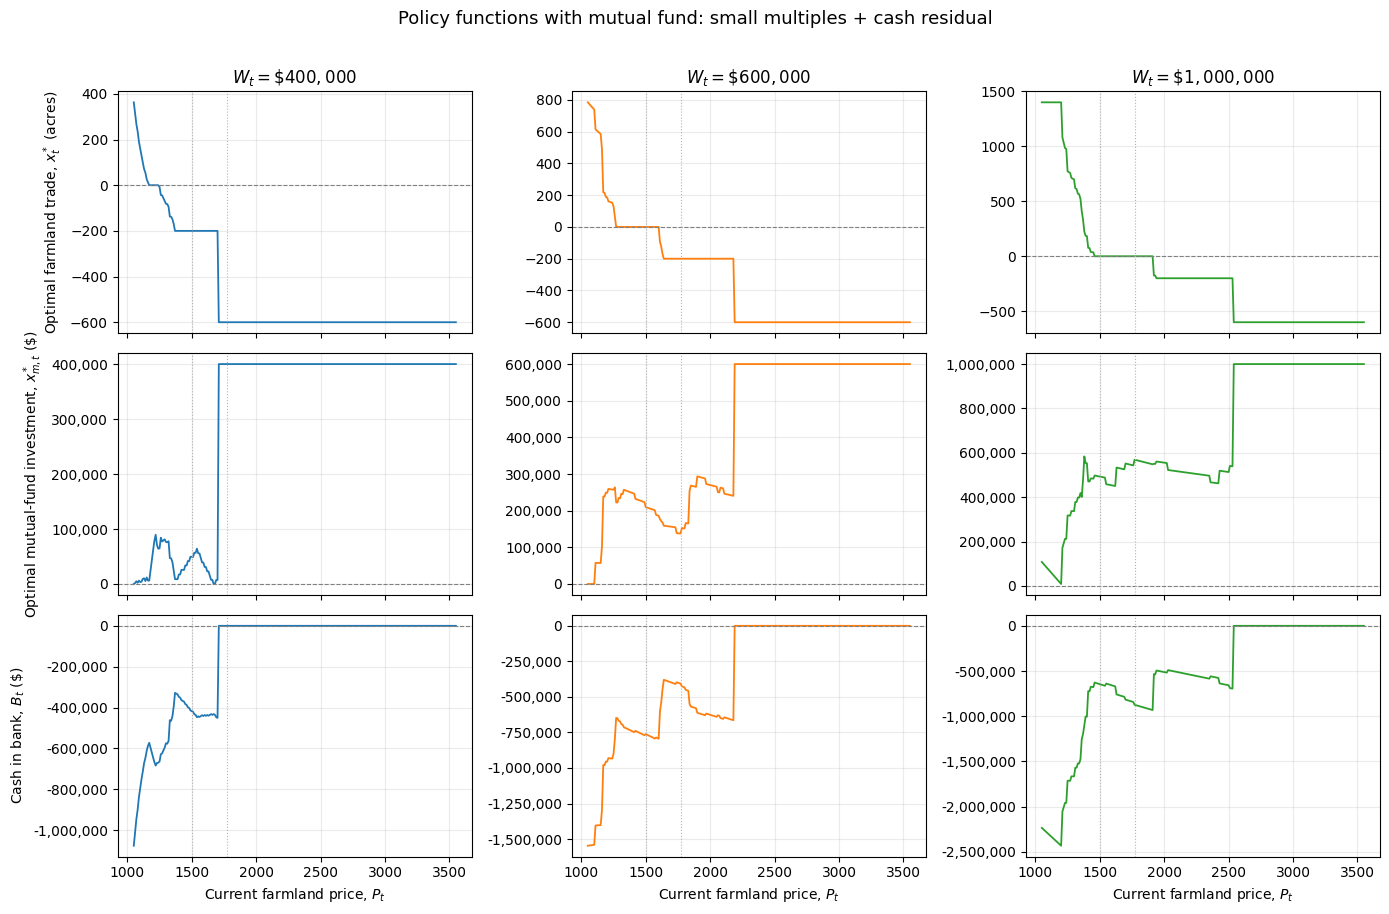

Saved figure to: Graphs/policy_small_multiples_mutual_with_bank.png


In [30]:
# Small-multiples policy visualization (option 1):
# rows = decisions, columns = wealth levels, x-axis = farmland price
from pathlib import Path
from matplotlib.ticker import FuncFormatter

if "cfg" not in globals():
    raise RuntimeError("cfg not found. Run the model setup cells first.")

if "copt_table7_mutual" in globals():
    copt_plot = copt_table7_mutual
elif "cache_key" in globals() and "_mutual_copt_cache" in globals() and cache_key in _mutual_copt_cache:
    copt_plot = _mutual_copt_cache[cache_key]
else:
    raise RuntimeError("No cached mutual coefficients found. Run coefficient-solve cells first.")

arrays_plot = build_model_arrays(cfg)
shock_nodes_plot, shock_weights_plot = gauss_hermite_multinormal(
    arrays_plot["m"], arrays_plot["Ee"], arrays_plot["VarCov"]
)

Rt = 365.0
Lt = 600.0
wealth_levels = [400_000.0, 600_000.0, 1_000_000.0]
P_grid = np.linspace(1050.0, 3550.0, 251)

land_curves = {}
mutual_curves = {}
bank_curves = {}
for W in wealth_levels:
    states = np.column_stack([
        np.full_like(P_grid, Rt, dtype=float),
        P_grid,
        np.full_like(P_grid, Lt, dtype=float),
        np.full_like(P_grid, W, dtype=float),
    ])
    x_opt, xm_opt, _ = mutual_vmaxh(
        states,
        copt_plot[:, 0],
        0,
        cfg,
        arrays_plot,
        shock_nodes_plot,
        shock_weights_plot,
    )
    x_star = np.asarray(x_opt, dtype=float)
    xm_star = np.asarray(xm_opt, dtype=float)
    land_curves[W] = x_star
    mutual_curves[W] = xm_star

    # Implied bank/cash residual after land and mutual-fund choices.
    sell_price_now = (1.0 - cfg.tcs) * P_grid + (1.0 - cfg.fds) * cfg.fme
    buy_price = (1.0 + cfg.tcb) * P_grid + cfg.fme
    sell_mask = x_star < 0.0
    buy_price[sell_mask] = (1.0 - cfg.tcs) * P_grid[sell_mask] + (1.0 - cfg.fds) * cfg.fme
    equity_now = W - sell_price_now * Lt
    eta = float(getattr(cfg, "cost_scale_eta", 1.0))
    lref = max(float(getattr(cfg, "cost_scale_ref", 600.0)), 1e-12)
    L_post = np.maximum(Lt + x_star, 0.0)
    operating_cost = cfg.cost * (lref ** (1.0 - eta)) * (L_post ** eta)
    bank_curves[W] = equity_now - buy_price * x_star - operating_cost - xm_star

fig, axes = plt.subplots(3, len(wealth_levels), figsize=(14, 9), sharex=True)
colors = ["tab:blue", "tab:orange", "tab:green"]
money_fmt = FuncFormatter(lambda x, _: f"{x:,.0f}")

for j, (W, c) in enumerate(zip(wealth_levels, colors)):
    ax_top = axes[0, j]
    ax_mid = axes[1, j]
    ax_bot = axes[2, j]

    ax_top.plot(P_grid, land_curves[W], color=c, linewidth=1.3)
    ax_top.axhline(0.0, color="0.5", linestyle="--", linewidth=0.8)
    ax_top.axvline(1500.0, color="0.7", linestyle=":", linewidth=0.8)
    ax_top.axvline(1775.0, color="0.7", linestyle=":", linewidth=0.8)
    ax_top.grid(alpha=0.25)
    ax_top.set_title(rf"$W_t=\${int(W):,}$")

    ax_mid.plot(P_grid, mutual_curves[W], color=c, linewidth=1.3)
    ax_mid.axhline(0.0, color="0.5", linestyle="--", linewidth=0.8)
    ax_mid.axvline(1500.0, color="0.7", linestyle=":", linewidth=0.8)
    ax_mid.axvline(1775.0, color="0.7", linestyle=":", linewidth=0.8)
    ax_mid.ticklabel_format(style="plain", axis="y", useOffset=False)
    ax_mid.yaxis.set_major_formatter(money_fmt)
    ax_mid.grid(alpha=0.25)

    ax_bot.plot(P_grid, bank_curves[W], color=c, linewidth=1.3)
    ax_bot.axhline(0.0, color="0.5", linestyle="--", linewidth=0.8)
    ax_bot.axvline(1500.0, color="0.7", linestyle=":", linewidth=0.8)
    ax_bot.axvline(1775.0, color="0.7", linestyle=":", linewidth=0.8)
    ax_bot.ticklabel_format(style="plain", axis="y", useOffset=False)
    ax_bot.yaxis.set_major_formatter(money_fmt)
    ax_bot.grid(alpha=0.25)
    ax_bot.set_xlabel("Current farmland price, $P_t$")

axes[0, 0].set_ylabel("Optimal farmland trade, $x_t^*$ (acres)")
axes[1, 0].set_ylabel(r"Optimal mutual-fund investment, $x_{m,t}^*$ (\$)")
axes[2, 0].set_ylabel(r"Cash in bank, $B_t$ (\$)")

fig.suptitle("Policy functions with mutual fund: small multiples + cash residual", y=1.01, fontsize=13)
fig.tight_layout()

Path("Graphs").mkdir(parents=True, exist_ok=True)
out_path = "Graphs/policy_small_multiples_mutual_with_bank.png"
plt.savefig(out_path, dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved figure to: {out_path}")


# $\rho$ comparison

Computing sensitivity analysis for rho/dau = 0.5 and 0.7...
Multiple scenarios across prices and wealth levels.

Sensitivity Analysis: rho/dau = 0.5 vs 0.7


,rho/dau,Price,Wealth,Initial DFA,Farmland trade (acres),Mutual fund investment ($),Final DFA
0,0.5,"$1,500","$400,000",0.605,-200,"46,650",0.477
1,0.5,"$1,500","$600,000",0.408,0,"93,300",0.500
2,0.5,"$1,500","$1,000,000",0.013,0,"493,300",0.500
3,0.5,"$1,775","$400,000",0.658,-600,"400,000",0.000
4,0.5,"$1,775","$600,000",0.487,-200,"149,104",0.421
5,0.5,"$1,775","$1,000,000",0.144,0,"415,750",0.500
6,0.7,"$1,500","$400,000",0.605,-200,"49,330",0.481
7,0.7,"$1,500","$600,000",0.408,0,"209,652",0.615
8,0.7,"$1,500","$1,000,000",0.013,0,"492,986",0.500
9,0.7,"$1,775","$400,000",0.658,-600,"400,000",0.000



Saved figure: rho_dau_comparison.png


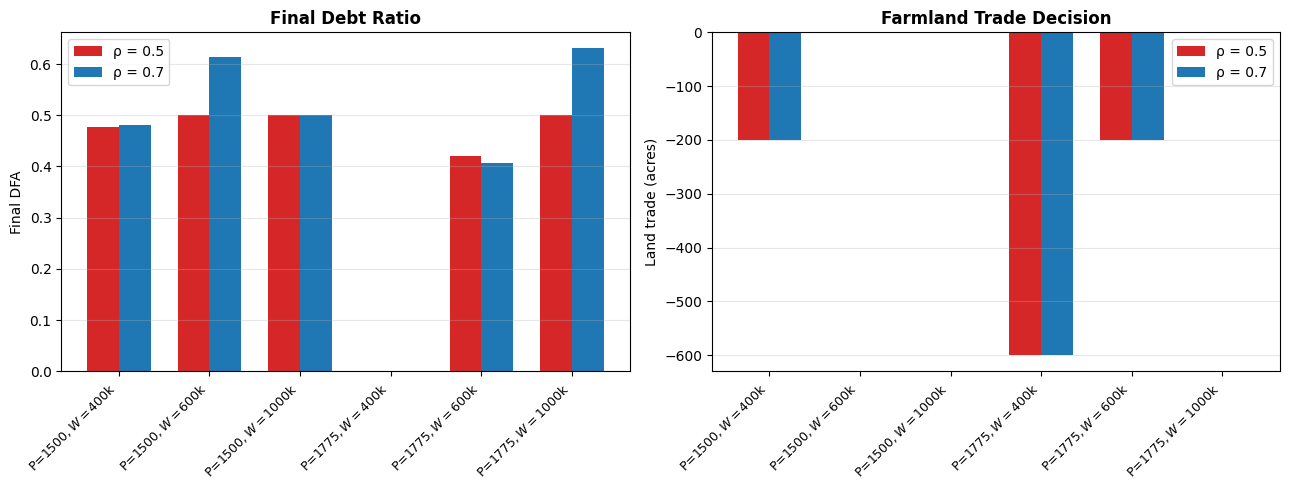

Saved LaTeX table: Tables/rho_dau_comparison.tex


In [13]:
# Sensitivity Analysis: compare rho/dau = 0.5 against the baseline rho/dau = 0.7
# Multiple scenarios like normal Table 7: prices and wealth levels

compare_daus = [0.5, float(cfg.dau)]
prices = [1500.0, 1775.0]
wealth_levels = [400_000.0, 600_000.0, 1_000_000.0]
reference_Rt = 365.0
reference_Lt = 600.0

comparison_rows = []

print("Computing sensitivity analysis for rho/dau = 0.5 and 0.7...")
print("Multiple scenarios across prices and wealth levels.\n")

for dau in compare_daus:
    if np.isclose(dau, float(cfg.dau)):
        cfg_sensitivity = cfg
        copt_sensitivity = copt_table7_mutual
        arrays_sens = arrays_m
        shock_nodes_sens = shock_nodes_m
        shock_weights_sens = shock_weights_m
    else:
        cfg_sensitivity = MutualFundConfig()
        cfg_sensitivity.dau = float(dau)
        cfg_sensitivity.Ee = (0.0, 0.0, 0.0)
        cfg_sensitivity.search_mode = "vectorized"
        cfg_sensitivity.value_backend = "numba"
        cfg_sensitivity.var_cov = (
            (0.030186, 0.0, 0.0),
            (0.0, 0.017292, 0.0),
            (0.0, 0.0, 0.026941),
        )
        cache_key_sens = (
            cfg_sensitivity.n,
            cfg_sensitivity.q,
            cfg_sensitivity.q2,
            cfg_sensitivity.m,
            cfg_sensitivity.T,
            cfg_sensitivity.t1,
            cfg_sensitivity.theta,
            cfg_sensitivity.b,
            cfg_sensitivity.dau,
            bool(cfg_sensitivity.CRRA),
            cfg_sensitivity.Ee,
            cfg_sensitivity.var_cov,
        )
        if cache_key_sens not in _mutual_copt_cache:
            print(f"  Solving for rho/dau={dau:.1f}...")
            _mutual_copt_cache[cache_key_sens] = solve_mutual_coefficients(cfg_sensitivity)
        copt_sensitivity = _mutual_copt_cache[cache_key_sens]
        arrays_sens = build_model_arrays(cfg_sensitivity)
        shock_nodes_sens, shock_weights_sens = gauss_hermite_multinormal(
            arrays_sens["m"], arrays_sens["Ee"], arrays_sens["VarCov"]
        )

    for price in prices:
        for wealth in wealth_levels:
            state = np.array([[reference_Rt, price, reference_Lt, wealth]], dtype=float)
            x_opt, xm_opt, _ = mutual_vmaxh(
                state,
                copt_sensitivity[:, 0],
                0,
                cfg_sensitivity,
                arrays_sens,
                shock_nodes_sens,
                shock_weights_sens,
            )
            x_star = float(x_opt[0])
            xm_star = float(xm_opt[0])
            comparison_rows.append({
                "rho/dau": f"{dau:.1f}",
                "Price": int(price),
                "Wealth": int(wealth),
                "Initial DFA": debt_to_farm_asset_ratio(price, reference_Lt, wealth),
                "Farmland trade (acres)": x_star,
                "Mutual fund investment ($)": xm_star,
                "Final DFA": resulting_dfa_after_trade(price, reference_Lt, wealth, x_star, xm_star),
            })

comparison_df = pd.DataFrame(comparison_rows)

display_table = comparison_df.copy()
display_table["Price"] = display_table["Price"].map(lambda v: f"${v:,.0f}")
display_table["Wealth"] = display_table["Wealth"].map(lambda v: f"${v:,.0f}")
display_table["Initial DFA"] = display_table["Initial DFA"].map(lambda v: f"{v:.3f}")
display_table["Farmland trade (acres)"] = display_table["Farmland trade (acres)"].map(lambda v: f"{v:,.0f}")
display_table["Mutual fund investment ($)"] = display_table["Mutual fund investment ($)"].map(lambda v: f"{v:,.0f}")
display_table["Final DFA"] = display_table["Final DFA"].map(lambda v: f"{v:.3f}")

print("=" * 100)
print("Sensitivity Analysis: rho/dau = 0.5 vs 0.7")
print("=" * 100)
display(display_table)

# Create grouped bar chart
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Plot 1: Final DFA comparison
plot_data = comparison_df.pivot_table(
    index=["Price", "Wealth"],
    columns="rho/dau",
    values="Final DFA"
).reset_index()
x_labels = [f"P=${int(p)}, W=${int(w)//1000}k" for p, w in zip(plot_data["Price"], plot_data["Wealth"])]
x_pos = np.arange(len(x_labels))
width = 0.35

axes[0].bar(x_pos - width/2, plot_data["0.5"], width, label="ρ = 0.5", color="#d62728")
axes[0].bar(x_pos + width/2, plot_data["0.7"], width, label="ρ = 0.7", color="#1f77b4")
axes[0].set_title("Final Debt Ratio", fontweight="bold")
axes[0].set_ylabel("Final DFA")
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(x_labels, rotation=45, ha="right", fontsize=9)
axes[0].legend()
axes[0].grid(axis="y", alpha=0.3)

# Plot 2: Farmland trade comparison
plot_data2 = comparison_df.pivot_table(
    index=["Price", "Wealth"],
    columns="rho/dau",
    values="Farmland trade (acres)"
).reset_index()

axes[1].bar(x_pos - width/2, plot_data2["0.5"], width, label="ρ = 0.5", color="#d62728")
axes[1].bar(x_pos + width/2, plot_data2["0.7"], width, label="ρ = 0.7", color="#1f77b4")
axes[1].set_title("Farmland Trade Decision", fontweight="bold")
axes[1].set_ylabel("Land trade (acres)")
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(x_labels, rotation=45, ha="right", fontsize=9)
axes[1].legend()
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("Graphs/rho_dau_comparison.png", dpi=300, bbox_inches="tight")
print("\nSaved figure: rho_dau_comparison.png")
plt.show()

latex_table = display_table.rename(columns={
    "rho/dau": r"$\rho$",
    "Price": "Price",
    "Wealth": "Wealth",
    "Initial DFA": "Initial DFA",
    "Farmland trade (acres)": "Land trade",
    "Mutual fund investment ($)": "MF invest.",
    "Final DFA": "Final DFA",
})
latex_str = latex_table.to_latex(
    index=False,
    escape=False,
    column_format="ccccccc",
    caption="Sensitivity Analysis: Effect of lowering credit limit parameter $\rho$ from 0.7 to 0.5",
    label="tab:rho_dau_sensitivity",
)
tex_path = "Tables/rho_dau_comparison.tex"
with open(tex_path, "w") as f:
    f.write(latex_str)
print(f"Saved LaTeX table: {tex_path}")

Computing CRRA vs CARA utility comparison...
Using baseline rho/dau = 0.7 for both.
CRRA theta = 1; CARA theta = 1/W_ref with W_ref=$600,000 -> 1.66667e-06

CRRA vs CARA Utility Comparison (rho/dau = 0.7, CARA calibrated at W_ref)


,Utility,Price,Wealth,Initial DFA,Farmland trade (acres),Mutual fund investment ($),Final DFA
0,CRRA,"$1,500","$400,000",0.605,-200,"49,330",0.481
1,CRRA,"$1,500","$600,000",0.408,0,"209,652",0.615
2,CRRA,"$1,500","$1,000,000",0.013,0,"492,986",0.500
3,CRRA,"$1,775","$400,000",0.658,-600,"400,000",0.000
4,CRRA,"$1,775","$600,000",0.487,-200,"137,362",0.406
5,CRRA,"$1,775","$1,000,000",0.144,0,"568,269",0.631
6,CARA,"$1,500","$400,000",0.605,-600,"400,000",0.000
7,CARA,"$1,500","$600,000",0.408,-600,"600,000",0.000
8,CARA,"$1,500","$1,000,000",0.013,-600,"1,000,000",0.000
9,CARA,"$1,775","$400,000",0.658,-600,"400,000",0.000



Saved figure: crra_cara_comparison.png


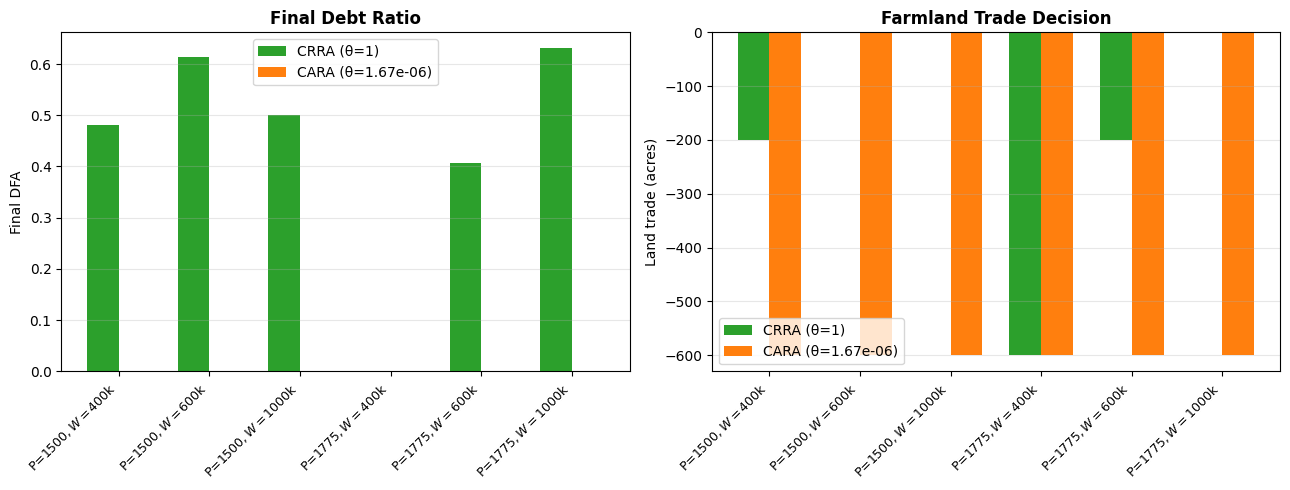

Saved LaTeX table: Tables/crra_cara_comparison.tex


In [14]:
# CRRA vs CARA Utility Comparison
# Compare risk preferences with CARA calibrated to match CRRA(log) ARA at a reference wealth.

compare_crra = [True, False]  # True=CRRA, False=CARA
prices = [1500.0, 1775.0]
wealth_levels = [400_000.0, 600_000.0, 1_000_000.0]
reference_Rt = 365.0
reference_Lt = 600.0

# Comparable calibration: match absolute risk aversion at W_ref
# CRRA with theta=1 (log utility) has ARA = 1/W, CARA has ARA = theta.
cara_ref_wealth = 600_000.0
theta_crra = 1.0
theta_cara = 1.0 / cara_ref_wealth

crra_cara_rows = []

print("Computing CRRA vs CARA utility comparison...")
print("Using baseline rho/dau = 0.7 for both.")
print(f"CRRA theta = {theta_crra:.6g}; CARA theta = 1/W_ref with W_ref=${cara_ref_wealth:,.0f} -> {theta_cara:.6g}\n")

for use_crra in compare_crra:
    cfg_utility = MutualFundConfig()
    cfg_utility.CRRA = use_crra
    cfg_utility.theta = theta_crra if use_crra else theta_cara
    cfg_utility.Ee = (0.0, 0.0, 0.0)
    cfg_utility.search_mode = "vectorized"
    cfg_utility.value_backend = "numba"
    cfg_utility.var_cov = (
        (0.030186, 0.0, 0.0),
        (0.0, 0.017292, 0.0),
        (0.0, 0.0, 0.026941),
    )

    cache_key_utility = (
        cfg_utility.n,
        cfg_utility.q,
        cfg_utility.q2,
        cfg_utility.m,
        cfg_utility.T,
        cfg_utility.t1,
        cfg_utility.theta,
        cfg_utility.b,
        cfg_utility.dau,
        bool(cfg_utility.CRRA),
        cfg_utility.Ee,
        cfg_utility.var_cov,
    )

    if cache_key_utility not in _mutual_copt_cache:
        utility_label = "CRRA" if use_crra else "CARA"
        print(f"  Solving for {utility_label} utility...")
        _mutual_copt_cache[cache_key_utility] = solve_mutual_coefficients(cfg_utility)

    copt_utility = _mutual_copt_cache[cache_key_utility]
    arrays_utility = build_model_arrays(cfg_utility)
    shock_nodes_utility, shock_weights_utility = gauss_hermite_multinormal(
        arrays_utility["m"], arrays_utility["Ee"], arrays_utility["VarCov"]
    )

    for price in prices:
        for wealth in wealth_levels:
            state = np.array([[reference_Rt, price, reference_Lt, wealth]], dtype=float)
            x_opt, xm_opt, _ = mutual_vmaxh(
                state,
                copt_utility[:, 0],
                0,
                cfg_utility,
                arrays_utility,
                shock_nodes_utility,
                shock_weights_utility,
            )
            x_star = float(x_opt[0])
            xm_star = float(xm_opt[0])
            crra_cara_rows.append({
                "Utility": "CRRA" if use_crra else "CARA",
                "Price": int(price),
                "Wealth": int(wealth),
                "Initial DFA": debt_to_farm_asset_ratio(price, reference_Lt, wealth),
                "Farmland trade (acres)": x_star,
                "Mutual fund investment ($)": xm_star,
                "Final DFA": resulting_dfa_after_trade(price, reference_Lt, wealth, x_star, xm_star),
            })

crra_cara_df = pd.DataFrame(crra_cara_rows)

display_crra_cara = crra_cara_df.copy()
display_crra_cara["Price"] = display_crra_cara["Price"].map(lambda v: f"${v:,.0f}")
display_crra_cara["Wealth"] = display_crra_cara["Wealth"].map(lambda v: f"${v:,.0f}")
display_crra_cara["Initial DFA"] = display_crra_cara["Initial DFA"].map(lambda v: f"{v:.3f}")
display_crra_cara["Farmland trade (acres)"] = display_crra_cara["Farmland trade (acres)"].map(lambda v: f"{v:,.0f}")
display_crra_cara["Mutual fund investment ($)"] = display_crra_cara["Mutual fund investment ($)"].map(lambda v: f"{v:,.0f}")
display_crra_cara["Final DFA"] = display_crra_cara["Final DFA"].map(lambda v: f"{v:.3f}")

print("=" * 100)
print("CRRA vs CARA Utility Comparison (rho/dau = 0.7, CARA calibrated at W_ref)")
print("=" * 100)
display(display_crra_cara)

# Create grouped bar chart
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Plot 1: Final DFA comparison
plot_data = crra_cara_df.pivot_table(
    index=["Price", "Wealth"],
    columns="Utility",
    values="Final DFA"
).reset_index()
x_labels = [f"P=${int(p)}, W=${int(w)//1000}k" for p, w in zip(plot_data["Price"], plot_data["Wealth"])]
x_pos = np.arange(len(x_labels))
width = 0.35

axes[0].bar(x_pos - width/2, plot_data["CRRA"], width, label=f"CRRA (θ={theta_crra:g})", color="#2ca02c")
axes[0].bar(x_pos + width/2, plot_data["CARA"], width, label=f"CARA (θ={theta_cara:.2e})", color="#ff7f0e")
axes[0].set_title("Final Debt Ratio", fontweight="bold")
axes[0].set_ylabel("Final DFA")
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(x_labels, rotation=45, ha="right", fontsize=9)
axes[0].legend()
axes[0].grid(axis="y", alpha=0.3)

# Plot 2: Farmland trade comparison
plot_data2 = crra_cara_df.pivot_table(
    index=["Price", "Wealth"],
    columns="Utility",
    values="Farmland trade (acres)"
).reset_index()

axes[1].bar(x_pos - width/2, plot_data2["CRRA"], width, label=f"CRRA (θ={theta_crra:g})", color="#2ca02c")
axes[1].bar(x_pos + width/2, plot_data2["CARA"], width, label=f"CARA (θ={theta_cara:.2e})", color="#ff7f0e")
axes[1].set_title("Farmland Trade Decision", fontweight="bold")
axes[1].set_ylabel("Land trade (acres)")
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(x_labels, rotation=45, ha="right", fontsize=9)
axes[1].legend()
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("Graphs/crra_cara_comparison.png", dpi=300, bbox_inches="tight")
print("\nSaved figure: crra_cara_comparison.png")
plt.show()

latex_table_crra = display_crra_cara.rename(columns={
    "Utility": "Utility",
    "Price": "Price",
    "Wealth": "Wealth",
    "Initial DFA": "Initial DFA",
    "Farmland trade (acres)": "Land trade",
    "Mutual fund investment ($)": "MF invest.",
    "Final DFA": "Final DFA",
})
latex_str_crra = latex_table_crra.to_latex(
    index=False,
    escape=False,
    column_format="cccccccc",
    caption="Utility Function Comparison: CRRA vs CARA preferences on optimal decisions (CARA calibrated by ARA match at W_ref)",
    label="tab:crra_cara_comparison",
)
tex_path_crra = "Tables/crra_cara_comparison.tex"
with open(tex_path_crra, "w") as f:
    f.write(latex_str_crra)
print(f"Saved LaTeX table: {tex_path_crra}")

In [15]:
# Diagnostic: inspect CRRA vs CARA results and flag odd rows
if 'crra_cara_df' in globals():
    df = crra_cara_df.copy()
    # Show raw numeric values for inspection
    pd.set_option('display.float_format', lambda x: f"{x:.6f}")
    print('Full CRRA/CARA table (raw values):')
    display(df.reset_index(drop=True))

    # Flag zero trades/investments
    df['FT_zero'] = np.isclose(df['Farmland trade (acres)'], 0.0)
    df['MF_zero'] = np.isclose(df['Mutual fund investment ($)'], 0.0)

    print('\nRows with no land trade or no mutual-fund investment:')
    display(df[(df['FT_zero']) | (df['MF_zero'])][['Utility','Price','Wealth','Farmland trade (acres)','Mutual fund investment ($)','Final DFA','FT_zero','MF_zero']])

    # Show specific rows 6,7,11 (1-based indexing) if present
    for r in [6,7,11]:
        idx = r - 1
        if idx < len(df):
            print(f"\nRow {r} (1-based):")
            display(df.iloc[[idx]][['Utility','Price','Wealth','Farmland trade (acres)','Mutual fund investment ($)','Final DFA']])
else:
    print('crra_cara_df not found in kernel. Run the CRRA/CARA comparison cell first.')


Full CRRA/CARA table (raw values):


,Utility,Price,Wealth,Initial DFA,Farmland trade (acres),Mutual fund investment ($),Final DFA
0,CRRA,1500,400000,0.605289,-200.000000,49330.000000,0.480950
1,CRRA,1500,600000,0.407934,0.000000,209652.500000,0.614814
2,CRRA,1500,1000000,0.013223,0.000000,492985.833333,0.499690
3,CRRA,1775,400000,0.657681,-600.000000,400000.000000,0.000000
4,CRRA,1775,600000,0.486521,-200.000000,137362.500000,0.406114
5,CRRA,1775,1000000,0.144202,0.000000,568268.750000,0.630525
6,CARA,1500,400000,0.605289,-600.000000,400000.000000,0.000000
7,CARA,1500,600000,0.407934,-600.000000,600000.000000,0.000000
8,CARA,1500,1000000,0.013223,-600.000000,1000000.000000,0.000000
9,CARA,1775,400000,0.657681,-600.000000,400000.000000,0.000000



Rows with no land trade or no mutual-fund investment:


,Utility,Price,Wealth,Farmland trade (acres),Mutual fund investment ($),Final DFA,FT_zero,MF_zero
1,CRRA,1500,600000,0.000000,209652.500000,0.614814,True,False
2,CRRA,1500,1000000,0.000000,492985.833333,0.499690,True,False
5,CRRA,1775,1000000,0.000000,568268.750000,0.630525,True,False



Row 6 (1-based):


,Utility,Price,Wealth,Farmland trade (acres),Mutual fund investment ($),Final DFA
5,CRRA,1775,1000000,0.000000,568268.750000,0.630525



Row 7 (1-based):


,Utility,Price,Wealth,Farmland trade (acres),Mutual fund investment ($),Final DFA
6,CARA,1500,400000,-600.000000,400000.000000,0.000000



Row 11 (1-based):


,Utility,Price,Wealth,Farmland trade (acres),Mutual fund investment ($),Final DFA
10,CARA,1775,600000,-600.000000,600000.000000,0.000000


In [12]:
# Diagnostic grid search for CARA problematic cases (use cached copt lookup)
from itertools import product

if 'crra_cara_df' in globals():
    cases = [
        {'Price':1500.0,'Wealth':400_000.0},
        {'Price':1500.0,'Wealth':600_000.0},
        {'Price':1775.0,'Wealth':600_000.0},
    ]
    use_crra = False
    theta = 1.0
    b = 60000.0
    dau = 0.7

    # Find matching cached copt
    cache_key_utility = None
    for k in _mutual_copt_cache.keys():
        try:
            if k[6] == theta and k[7] == b and k[8] == dau and (k[9] is False or k[9] == use_crra):
                cache_key_utility = k
                break
        except Exception:
            continue
    if cache_key_utility is None:
        raise RuntimeError('No matching cached copt found for CARA settings')

    copt_utility = _mutual_copt_cache[cache_key_utility]
    arrays_utility = build_model_arrays(MutualFundConfig())
    shock_nodes_utility, shock_weights_utility = gauss_hermite_multinormal(arrays_utility['m'], arrays_utility['Ee'], arrays_utility['VarCov'])

    for case in cases:
        P = case['Price']
        W = case['Wealth']
        state = np.array([[reference_Rt, P, reference_Lt, W]], dtype=float)
        xl, xu = mutual_bounds_x(state, MutualFundConfig())
        trade_grid = np.linspace(xl[0], xu[0], num=9)
        best_val = -1e99
        best_control = (0.0, 0.0)
        for tx in trade_grid:
            tx_arr = np.array([tx])
            xml, xmu = mutual_bounds_xm(state, tx_arr, MutualFundConfig())
            xm_grid = np.linspace(xml[0], xmu[0], num=9)
            for xm in xm_grid:
                controls = np.array([[tx, xm]])
                val = mutual_value_function(state, copt_utility, 0, controls, MutualFundConfig(), arrays_utility, shock_nodes_utility, shock_weights_utility)[0]
                if val > best_val:
                    best_val = float(val)
                    best_control = (float(tx), float(xm))
        zero_controls = np.array([[0.0, 0.0]])
        zero_val = mutual_value_function(state, copt_utility, 0, zero_controls, MutualFundConfig(), arrays_utility, shock_nodes_utility, shock_weights_utility)[0]
        print(f"Case P={int(P)}, W={int(W)} (CARA): best_val={best_val:.6f} at control={best_control}; zero_val={zero_val:.6f}")
        if np.isclose(best_control[0], 0.0) and np.isclose(best_control[1], 0.0):
            print("  -> Grid search confirms zero control is best within sampled bounds.")
        else:
            print("  -> Grid search found a better control; consider using finer grid or inspecting bounds.")
else:
    print('crra_cara_df not available; run comparison cell first.')


RuntimeError: No matching cached copt found for CARA settings

In [ ]:
# Quick inspect cache keys and shapes
for k, v in _mutual_copt_cache.items():
    try:
        print(k, np.shape(v))
    except Exception as e:
        print('key', k, 'error:', e)


((7, 7, 5, 21), 21, 5, (3, 3, 3), 19, 1, 1.0, 60000.0, np.float64(0.3), True, (0.0, 0.0, 0.0), ((0.030186, 0.0, 0.0), (0.0, 0.017292, 0.0), (0.0, 0.0, 0.026941))) (5145, 19)
((7, 7, 5, 21), 21, 5, (3, 3, 3), 19, 1, 1.0, 60000.0, 0.5, True, (0.0, 0.0, 0.0), ((0.030186, 0.0, 0.0), (0.0, 0.017292, 0.0), (0.0, 0.0, 0.026941))) (5145, 19)
((7, 7, 5, 21), 41, 25, (3, 3, 3), 19, 1, 1.0, 60000.0, 0.7, True, (0.0, 0.0, 0.0), ((0.030186, 0.0, 0.0), (0.0, 0.017292, 0.0), (0.0, 0.0, 0.026941))) (5145, 19)
((7, 7, 5, 21), 21, 5, (3, 3, 3), 19, 1, 1.0, 60000.0, 0.7, True, (0.0, 0.0, 0.0), ((0.030186, 0.0, 0.0), (0.0, 0.017292, 0.0), (0.0, 0.0, 0.026941))) (5145, 19)
((7, 7, 5, 21), 21, 5, (3, 3, 3), 19, 1, 1.0, 60000.0, 0.7, False, (0.0, 0.0, 0.0), ((0.030186, 0.0, 0.0), (0.0, 0.017292, 0.0), (0.0, 0.0, 0.026941))) (5145, 19)


In [16]:
import numpy as np
import pandas as pd
import copy

# Extension: economies of scale in operating costs
# total_cost(L) = cost * (L_ref ** (1-eta)) * L**eta
# eta=1.0 => baseline linear cost.


def _table8_with_scale_eta(scale_eta, seed=42, n_sims=500, n_years=10):
    rng = np.random.default_rng(seed)

    cfg_ext = copy.deepcopy(cfg)   # <- exact baseline config
    cfg_ext.cost_scale_eta = float(scale_eta)
    cfg_ext.cost_scale_ref = 600.0
    

    if "_mutual_copt_cache" not in globals() or not isinstance(_mutual_copt_cache, dict):
        globals()["_mutual_copt_cache"] = {}

    cache_key = (
        cfg_ext.n,
        cfg_ext.q,
        cfg_ext.q2,
        cfg_ext.qf,
        cfg_ext.m,
        cfg_ext.T,
        cfg_ext.t1,
        cfg_ext.theta,
        cfg_ext.b,
        cfg_ext.dau,
        bool(cfg_ext.CRRA),
        cfg_ext.Ee,
        cfg_ext.var_cov,
        cfg_ext.cost,
        cfg_ext.cost_scale_eta,
        cfg_ext.cost_scale_ref,
    )

    if cache_key not in _mutual_copt_cache:
        print(f"Solving coefficients for eta={scale_eta:.2f}...")
        _mutual_copt_cache[cache_key] = solve_mutual_coefficients(cfg_ext)
    copt_ext = _mutual_copt_cache[cache_key]

    arrays = build_model_arrays(cfg_ext)
    shock_nodes, shock_weights = gauss_hermite_multinormal(arrays["m"], arrays["Ee"], arrays["VarCov"])

    mean_e = np.asarray(cfg_ext.Ee, dtype=float)
    cov_e = np.asarray(cfg_ext.var_cov, dtype=float)

    states = np.zeros((n_sims, 4), dtype=float)
    states[:, 0] = 365.0
    states[:, 1] = 1775.0
    states[:, 2] = 600.0
    states[:, 3] = 1_000_000.0

    rows = [{
        "Year": 0,
        "Expected net wealth ($)": states[:, 3].mean(),
        "Expected farmland (acres)": states[:, 2].mean(),
        "Prob. of exiting farming": 0.0,
    }]

    for year in range(1, n_years + 1):
        yr_idx = year - 1
        coeffs_t = copt_ext[:, yr_idx]
        active_mask = (states[:, 2] >= (arrays["sminv"][2] - 1.0)) & (states[:, 3] > 0.0)
        active_idx = np.where(active_mask)[0]
        next_states = states.copy()

        if active_idx.size > 0:
            active_states = states[active_idx]
            x_opt, xm_opt, _ = mutual_vmaxh(active_states, coeffs_t, yr_idx, cfg_ext, arrays, shock_nodes, shock_weights)
            # Match previous Table 8 protocol: draw shocks fresh each year for active farmers.
            shocks = rng.multivariate_normal(mean=mean_e, cov=cov_e, size=active_idx.size)
            next_active = mutual_transition_next_state(active_states, x_opt, xm_opt, shocks, cfg_ext, arrays["sminv"], arrays["smaxv"])
            next_states[active_idx] = next_active

        out_idx = np.where(~active_mask)[0]
        if out_idx.size > 0:
            next_states[out_idx, 2] = 0.0
            positive_wealth = next_states[out_idx, 3] >= 0.0
            next_states[out_idx[positive_wealth], 3] = cfg_ext.EgRM * next_states[out_idx[positive_wealth], 3]
            next_states[out_idx[~positive_wealth], 3] = (1.0 + cfg_ext.rn) * next_states[out_idx[~positive_wealth], 3]

        states = next_states
        exited = (states[:, 2] < 1.0) | (states[:, 3] <= 0.0)
        rows.append({
            "Year": year,
            "Expected net wealth ($)": states[:, 3].mean(),
            "Expected farmland (acres)": states[:, 2].mean(),
            "Prob. of exiting farming": exited.mean(),
        })

    df = pd.DataFrame(rows)
    return {
        "eta": float(scale_eta),
        "Year 10 expected wealth ($)": df.loc[df["Year"] == n_years, "Expected net wealth ($)"].iloc[0],
        "Year 10 expected farmland (acres)": df.loc[df["Year"] == n_years, "Expected farmland (acres)"].iloc[0],
        "Year 10 exit probability": df.loc[df["Year"] == n_years, "Prob. of exiting farming"].iloc[0],
        "Avg exit probability (Y1-Y10)": df.loc[df["Year"] >= 1, "Prob. of exiting farming"].mean(),
    }


eta_scenarios = [1.00, 0.90, 0.80]
results = [_table8_with_scale_eta(eta) for eta in eta_scenarios]
extension_results_df = pd.DataFrame(results)

for col in [
    "Year 10 expected wealth ($)",
    "Year 10 expected farmland (acres)",
    "Year 10 exit probability",
    "Avg exit probability (Y1-Y10)",
]:
    if "wealth" in col or "farmland" in col:
        extension_results_df[col] = extension_results_df[col].map(lambda v: f"{v:,.0f}")
    else:
        extension_results_df[col] = extension_results_df[col].map(lambda v: f"{v:.3f}")

print("Economies-of-scale extension results (lower eta => stronger scale economies):")
display(extension_results_df)


Solving coefficients for eta=1.00...
Solving coefficients for eta=0.90...
Solving coefficients for eta=0.80...
Economies-of-scale extension results (lower eta => stronger scale economies):


,eta,Year 10 expected wealth ($),Year 10 expected farmland (acres),Year 10 exit probability,Avg exit probability (Y1-Y10)
0,1.000000,"2,368,074",948,0.132,0.058
1,0.900000,"2,544,038","1,204",0.092,0.035
2,0.800000,"2,849,691","1,428",0.038,0.013
